## Zero-Order Model - Baseline Model - Predicts Mean CGM Value

In [1]:
!python -m ensurepip --upgrade
!pip install -r ../requirements.txt

Looking in links: c:\Users\msbdj\AppData\Local\Temp\tmp1wliqtc5


## 30 Minute Prediction Horizon

Using subject id: 540
Total samples: 14842, train: 11873, test: 2969, n_predictions: 6
Zero-order hold baseline evaluation on test data (flattened across horizon):
  Samples (windows): 2963
  Horizon steps: 6
  MSE: 387.168
  RMSE: 19.677
  MAE: 13.182
  MARE (overall, %): 9.159


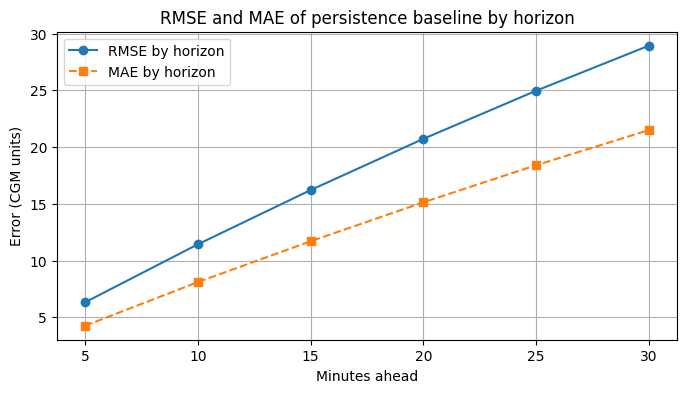

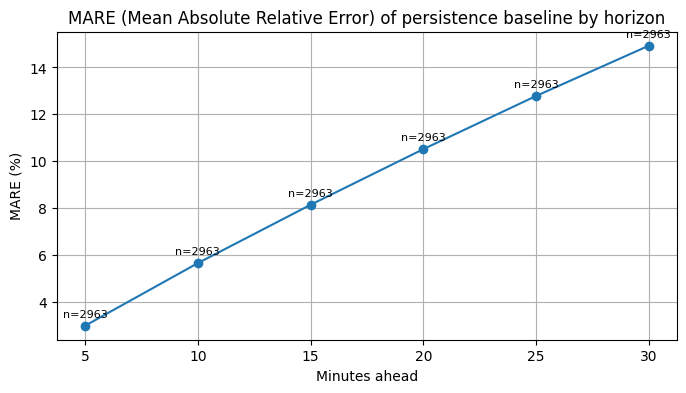

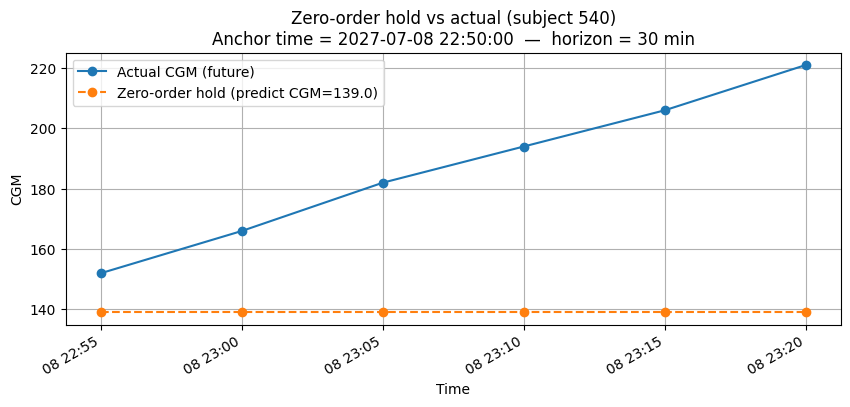

,anchor_time,last_cgm,actual_future_first,predicted_const
0,2027-07-03 18:00:00,238.0,240.0,238.0
1,2027-07-03 18:05:00,240.0,242.0,240.0
2,2027-07-03 18:10:00,242.0,243.0,242.0
3,2027-07-03 18:15:00,243.0,243.0,243.0
4,2027-07-03 18:20:00,243.0,244.0,243.0


In [3]:
# Zero-order hold (persistence) baseline for CGM
# With added per-horizon RMSE and MARE (mean absolute relative error) metrics & plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------- configuration --------
DATA_PATH = "../data/OhioT1DM.csv"
PRED_HORIZ_MIN = 30        # prediction horizon in minutes (e.g., 30-min)
STEP_MIN = 5               # sampling interval in minutes (assumed)
TEST_FRACTION = 0.2        # time-based test split fraction
SUBJECT_TO_PLOT = None     # None -> will pick first subject automatically
RNG = 42
# -------------------------------

# load and clean
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# drop rows without CGM (can't use those for persistence)
df = df.dropna(subset=['CGM']).reset_index(drop=True)

# choose a subject (id)
subject_ids = df['id'].unique()
if SUBJECT_TO_PLOT is None:
    subject_id = subject_ids[0]
else:
    subject_id = SUBJECT_TO_PLOT
print("Using subject id:", subject_id)

sub = df[df['id'] == subject_id].copy().reset_index(drop=True)

# prediction horizon in number of samples
n_predictions = PRED_HORIZ_MIN // STEP_MIN

# time-based train/test split (use earliest 80% as train, last 20% as test)
n_total = len(sub)
split_idx = int((1 - TEST_FRACTION) * n_total)

train_df = sub.iloc[:split_idx].reset_index(drop=True)
test_df = sub.iloc[split_idx:].reset_index(drop=True)

print(f"Total samples: {n_total}, train: {len(train_df)}, test: {len(test_df)}, n_predictions: {n_predictions}")

# Build test samples for evaluation:
X_last = []      # scalar last CGM at anchor time i
Y_future = []    # vector of length n_predictions (actual future values)
times_future = []  # times corresponding to the future values (for optional plotting alignment)

for i in range(len(test_df) - n_predictions):
    last_cgm = test_df.loc[i, 'CGM']
    future_slice = test_df.loc[i + 1: i + n_predictions, 'CGM'].values
    future_times = test_df.loc[i + 1: i + n_predictions, 'date'].values
    if len(future_slice) == n_predictions:
        X_last.append(last_cgm)
        Y_future.append(future_slice)
        times_future.append(future_times)

X_last = np.array(X_last)                     # shape (N_samples,)
Y_future = np.array(Y_future)                 # shape (N_samples, n_predictions)
times_future = np.array(times_future)         # shape (N_samples, n_predictions) dtype datetime64

if Y_future.size == 0:
    raise ValueError("No valid test windows found. Check test split or n_predictions.")

# Zero-order hold prediction: repeat last observed CGM across horizon
Y_pred = np.repeat(X_last[:, None], n_predictions, axis=1)  # shape (N_samples, n_predictions)

# Flatten for overall metrics (compare every predicted future point)
y_true_flat = Y_future.ravel()
y_pred_flat = Y_pred.ravel()

mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)

# MARE (mean absolute relative error) overall: avoid divide-by-zero by masking zeros
eps = 1e-8
mask_nonzero = (y_true_flat != 0)
if mask_nonzero.sum() == 0:
    overall_mare = np.nan
else:
    overall_mare = np.mean(np.abs((y_true_flat[mask_nonzero] - y_pred_flat[mask_nonzero]) / y_true_flat[mask_nonzero])) * 100.0

print(f"Zero-order hold baseline evaluation on test data (flattened across horizon):")
print(f"  Samples (windows): {Y_future.shape[0]}")
print(f"  Horizon steps: {n_predictions}")
print(f"  MSE: {mse:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE: {mae:.3f}")
print(f"  MARE (overall, %): {overall_mare:.3f}")

# --- Per-horizon metrics (for each step ahead: +5, +10, ... minutes) ---
# MSE per step (axis=0), then RMSE
mse_per_step = np.mean((Y_future - Y_pred)**2, axis=0)    # length n_predictions
rmse_per_step = np.sqrt(mse_per_step)

# MAE per step
mae_per_step = np.mean(np.abs(Y_future - Y_pred), axis=0)

# MARE per step (in percent). Handle zeros by using NaN and computing nanmean for that step.
mare_per_step = []
count_nonzero_per_step = []
for step in range(n_predictions):
    y_t = Y_future[:, step]
    y_p = Y_pred[:, step]
    nz_mask = (y_t != 0)
    count_nonzero_per_step.append(int(nz_mask.sum()))
    if nz_mask.sum() == 0:
        mare_per_step.append(np.nan)
    else:
        mare_val = np.mean(np.abs((y_t[nz_mask] - y_p[nz_mask]) / y_t[nz_mask])) * 100.0
        mare_per_step.append(mare_val)
mare_per_step = np.array(mare_per_step)

# x positions in minutes ahead
steps = np.arange(1, n_predictions + 1) * STEP_MIN

# --- Plots ---
plt.figure(figsize=(8,4))
plt.plot(steps, rmse_per_step, marker='o', linestyle='-', label='RMSE by horizon')
plt.plot(steps, mae_per_step, marker='s', linestyle='--', label='MAE by horizon')
plt.xlabel('Minutes ahead')
plt.ylabel('Error (CGM units)')
plt.title('RMSE and MAE of persistence baseline by horizon')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(steps, mare_per_step, marker='o', linestyle='-')
for i, cnt in enumerate(count_nonzero_per_step):
    plt.annotate(f"n={cnt}", (steps[i], mare_per_step[i]), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
plt.xlabel('Minutes ahead')
plt.ylabel('MARE (%)')
plt.title('MARE (Mean Absolute Relative Error) of persistence baseline by horizon')
plt.grid(True)
plt.show()

# --- Single window plot: actual vs zero-order hold prediction for one example anchor ---
example_idx = max(0, len(Y_future)//2)  # pick a middle window example
y_actual = Y_future[example_idx]         # length n_predictions
y_pred_single = Y_pred[example_idx]      # repeated scalar
t_future = pd.to_datetime(times_future[example_idx])  # convert to pandas datetimes

plt.figure(figsize=(10,4))
plt.plot(t_future, y_actual, marker='o', linestyle='-', label='Actual CGM (future)')
plt.plot(t_future, y_pred_single, marker='o', linestyle='--', label=f'Zero-order hold (predict CGM={X_last[example_idx]:.1f})')
plt.xlabel('Time')
plt.ylabel('CGM')
plt.title(f'Zero-order hold vs actual (subject {subject_id})\nAnchor time = {test_df.loc[example_idx, "date"]}  —  horizon = {PRED_HORIZ_MIN} min')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# Optionally: show a small table of first 5 examples (anchor_time, last_cgm, actual_future[0], ... )
display_df = []
for j in range(min(5, len(Y_future))):
    anchor_time = test_df.loc[j, 'date']
    display_df.append({
        "anchor_time": anchor_time,
        "last_cgm": X_last[j],
        "actual_future_first": Y_future[j, 0],
        "predicted_const": X_last[j]
    })
display(pd.DataFrame(display_df))


C:\Users\msbdj\AppData\Local\Temp\ipykernel_16876\940785642.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_interval = df.groupby("id").apply(med_int).dropna().median()


subjects total/train/test = 12/9/3
samples train/test = 124690/41770  (steps=6)
Test RMSE = 27.21 mg/dL, MAE = 19.36 mg/dL


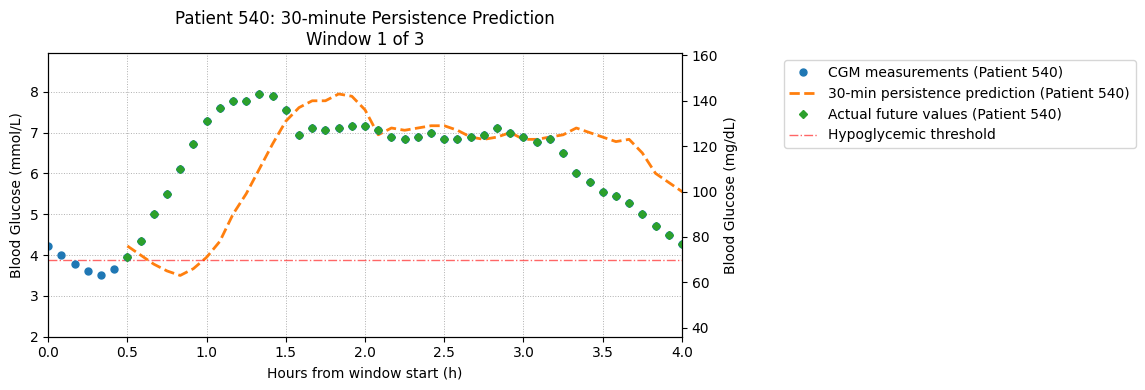

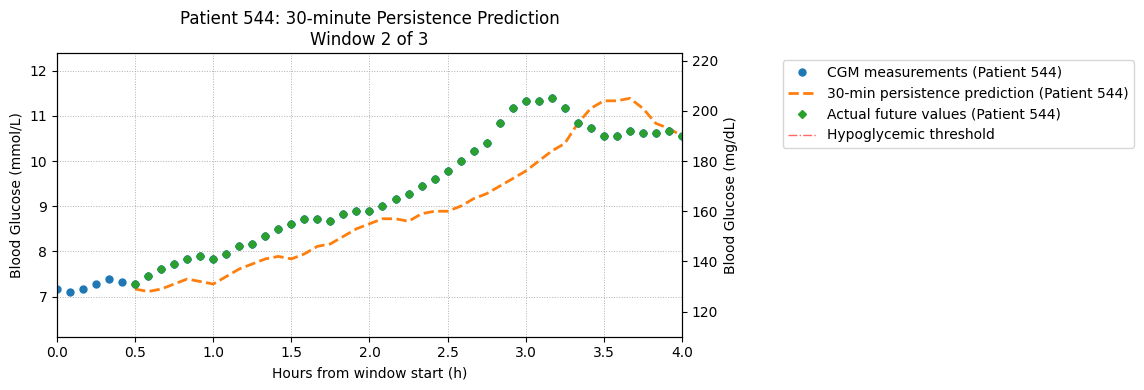

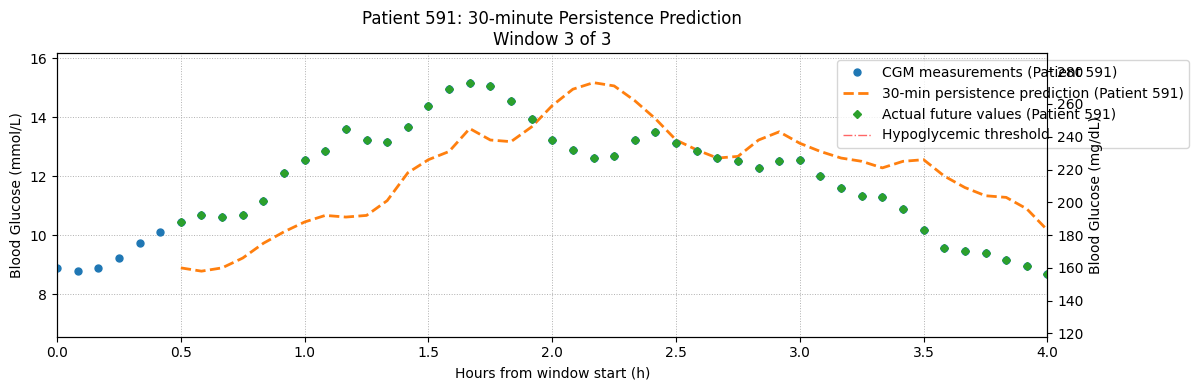

In [4]:
# Single notebook cell: minimal persistence (zero-order hold) baseline with 30-min delay
import os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

random.seed(42); np.random.seed(42)
DATA = "../data/OhioT1DM.csv"   # adjust if needed
PH_MIN = 30                    # prediction horizon in minutes
TRAIN_FRACT = 0.8
WINDOW_HOURS = 4

if not os.path.exists(DATA):
    raise FileNotFoundError(f"File not found: {DATA}")

df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["id","date"]).reset_index(drop=True)
df = df.dropna(subset=["CGM"]).copy()
df["CGM"] = pd.to_numeric(df["CGM"], errors="coerce")

# get median sampling interval (minutes)
def med_int(g): 
    d = g["date"].diff().dt.total_seconds().dropna()/60.0
    return d.median() if len(d)>0 else np.nan
median_interval = df.groupby("id").apply(med_int).dropna().median()
if np.isnan(median_interval): raise RuntimeError("Cannot infer sampling interval.")
steps = max(1, int(round(PH_MIN/median_interval)))

# build supervised rows: target = CGM at t + steps (per subject)
rows = []
for sid, g in df.groupby("id"):
    g = g.reset_index(drop=True)
    if len(g) <= steps: continue
    g["target_CGM"] = g["CGM"].shift(-steps)
    g["pred_time"] = g["date"] + pd.Timedelta(minutes=PH_MIN)   # when the persistence prediction actually applies
    rows.append(g.loc[~g["target_CGM"].isna(), ["id","date","CGM","pred_time","target_CGM"]])
data = pd.concat(rows).reset_index(drop=True)
if data.empty: raise RuntimeError("No supervised samples found.")

# subject-level split (no leakage)
subjects = sorted(data["id"].unique()); random.shuffle(subjects)
ntrain = int(len(subjects)*TRAIN_FRACT)
train_s = set(subjects[:ntrain]); test_s = set(subjects[ntrain:])
train = data[data["id"].isin(train_s)].reset_index(drop=True)
test  = data[data["id"].isin(test_s)].reset_index(drop=True)
print(f"subjects total/train/test = {len(subjects)}/{len(train_s)}/{len(test_s)}")
print(f"samples train/test = {len(train)}/{len(test)}  (steps={steps})")

# persistence prediction: prediction at pred_time equals CGM at current time
y_true = test["target_CGM"].values
y_pred = test["CGM"].values
rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
print(f"Test RMSE = {rmse_mgdl:.2f} mg/dL, MAE = {mae_mgdl:.2f} mg/dL")

# convert to mmol/L for plotting (1 mmol/L = 18 mg/dL)
test["target_mmol"] = test["target_CGM"]/18.0
test["pred_mmol"]   = test["CGM"]/18.0
test["actual_mmol"] = test["CGM"]/18.0  # same numeric values, plotted at different times

# plotting: up to 3 windows from distinct test subjects
hyp_mmol = 70.0/18.0
test_subjects = list(test["id"].unique())[:6]
count = 0
for sid in test_subjects:
    if count>=3: break
    sub = test[test["id"]==sid].sort_values("date").reset_index(drop=True)
    if len(sub) < 5: continue
    start = sub["date"].iloc[0]
    # include rows whose original time or pred_time falls within 0..WINDOW_HOURS from start
    mask = ((sub["date"] - start).dt.total_seconds() <= WINDOW_HOURS*3600) | \
           ((sub["pred_time"] - start).dt.total_seconds() <= WINDOW_HOURS*3600)
    win = sub.loc[mask].copy()
    if win.empty: continue

    x_actual = (win["date"] - start).dt.total_seconds()/3600.0
    x_pred   = (win["pred_time"] - start).dt.total_seconds()/3600.0

    fig, ax1 = plt.subplots(figsize=(12,4))  # Wider figure to accommodate legend
    
    # Plot on primary axis
    l1 = ax1.plot(x_actual, win["actual_mmol"], 'o', markersize=5, 
             label=f"CGM measurements (Patient {sid})", zorder=3)
    order = np.argsort(x_pred)
    l2 = ax1.plot(x_pred.values[order], win["pred_mmol"].values[order], 
             linestyle="--", linewidth=2, 
             label=f"30-min persistence prediction (Patient {sid})", zorder=2)
    l3 = ax1.plot(x_pred, win["target_mmol"], 'D', markersize=4, 
             label=f"Actual future values (Patient {sid})", zorder=4)
    
    ax1.set_xlim(0, WINDOW_HOURS)
    ax1.set_ylim(max(0, min(win["actual_mmol"].min(), win["pred_mmol"].min(), win["target_mmol"].min())-1),
             max(win["actual_mmol"].max(), win["pred_mmol"].max(), win["target_mmol"].max())+1)
    ax1.set_xlabel("Hours from window start (h)")
    ax1.set_ylabel("Blood Glucose (mmol/L)")
    ax1.grid(linestyle=':', linewidth=0.7)
    
    # Second y-axis in mg/dL
    ax2 = ax1.twinx()
    ax2.set_ylim(ax1.get_ylim()[0]*18, ax1.get_ylim()[1]*18)
    ax2.set_ylabel("Blood Glucose (mg/dL)")
    
    # Add hypoglycemia threshold line
    l4 = ax1.axhline(hyp_mmol, linestyle='-.', linewidth=1, alpha=0.6, color='red', 
                     label='Hypoglycemic threshold')
    
    # Combine legends from both axes
    lines = l1 + l2 + l3 + [l4]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, bbox_to_anchor=(1.15, 1))
    
    plt.title(f"Patient {sid}: 30-minute Persistence Prediction\nWindow {count+1} of 3")
    plt.tight_layout()
    plt.show()
    count += 1